In [1]:
!pip install -q transformers torch pandas matplotlib seaborn wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from transformers import pipeline
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
feedback_data = {
    "Customer_ID": [
        "C001", "C002", "C003", "C004", "C005",
        "C006", "C007", "C008", "C009", "C010",
        "C011", "C012", "C013", "C014", "C015"
    ],

    "Feedback": [
        "The product quality is excellent and I am very satisfied.",
        "The delivery was extremely late and disappointing.",
        "Customer service was helpful and solved my problem quickly.",
        "The application keeps crashing and is very frustrating.",
        "I really love this product. It works perfectly.",
        "The product is okay, nothing special.",
        "The support team was rude and unhelpful.",
        "Fast delivery and excellent packaging.",
        "I am unhappy with the quality of the product.",
        "The new update is amazing and very useful.",
        "The price is reasonable for the quality.",
        "My order arrived damaged and I want a replacement.",
        "Very easy to use and the experience was great.",
        "The service is average and could be improved.",
        "I am extremely happy with my purchase."
    ]
}

df = pd.DataFrame(feedback_data)

df

,Customer_ID,Feedback
0,C001,The product quality is excellent and I am very...
1,C002,The delivery was extremely late and disappoint...
2,C003,Customer service was helpful and solved my pro...
3,C004,The application keeps crashing and is very fru...
4,C005,I really love this product. It works perfectly.
5,C006,"The product is okay, nothing special."
6,C007,The support team was rude and unhelpful.
7,C008,Fast delivery and excellent packaging.
8,C009,I am unhappy with the quality of the product.
9,C010,The new update is amazing and very useful.


In [4]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [5]:
results = []

for text in df["Feedback"]:
    result = sentiment_model(text)[0]

    results.append({
        "Sentiment": result["label"],
        "Confidence": round(result["score"], 4)
    })

result_df = pd.DataFrame(results)

df = pd.concat([df, result_df], axis=1)

df

,Customer_ID,Feedback,Sentiment,Confidence
0,C001,The product quality is excellent and I am very...,POSITIVE,0.9999
1,C002,The delivery was extremely late and disappoint...,NEGATIVE,0.9997
2,C003,Customer service was helpful and solved my pro...,POSITIVE,0.9431
3,C004,The application keeps crashing and is very fru...,NEGATIVE,0.9995
4,C005,I really love this product. It works perfectly.,POSITIVE,0.9999
5,C006,"The product is okay, nothing special.",NEGATIVE,0.9859
6,C007,The support team was rude and unhelpful.,NEGATIVE,0.9991
7,C008,Fast delivery and excellent packaging.,POSITIVE,0.9998
8,C009,I am unhappy with the quality of the product.,NEGATIVE,0.9998
9,C010,The new update is amazing and very useful.,POSITIVE,0.9999


In [6]:
def classify_sentiment(row):
    if row["Confidence"] < 0.65:
        return "Neutral"
    return row["Sentiment"].capitalize()

df["Final_Sentiment"] = df.apply(classify_sentiment, axis=1)

df

,Customer_ID,Feedback,Sentiment,Confidence,Final_Sentiment
0,C001,The product quality is excellent and I am very...,POSITIVE,0.9999,Positive
1,C002,The delivery was extremely late and disappoint...,NEGATIVE,0.9997,Negative
2,C003,Customer service was helpful and solved my pro...,POSITIVE,0.9431,Positive
3,C004,The application keeps crashing and is very fru...,NEGATIVE,0.9995,Negative
4,C005,I really love this product. It works perfectly.,POSITIVE,0.9999,Positive
5,C006,"The product is okay, nothing special.",NEGATIVE,0.9859,Negative
6,C007,The support team was rude and unhelpful.,NEGATIVE,0.9991,Negative
7,C008,Fast delivery and excellent packaging.,POSITIVE,0.9998,Positive
8,C009,I am unhappy with the quality of the product.,NEGATIVE,0.9998,Negative
9,C010,The new update is amazing and very useful.,POSITIVE,0.9999,Positive


In [7]:
sentiment_counts = df["Final_Sentiment"].value_counts()

print("Customer Feedback Summary")
print("-------------------------")

for sentiment, count in sentiment_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{sentiment}: {count} ({percentage:.1f}%)")

Customer Feedback Summary
-------------------------
Positive: 8 (53.3%)
Negative: 7 (46.7%)


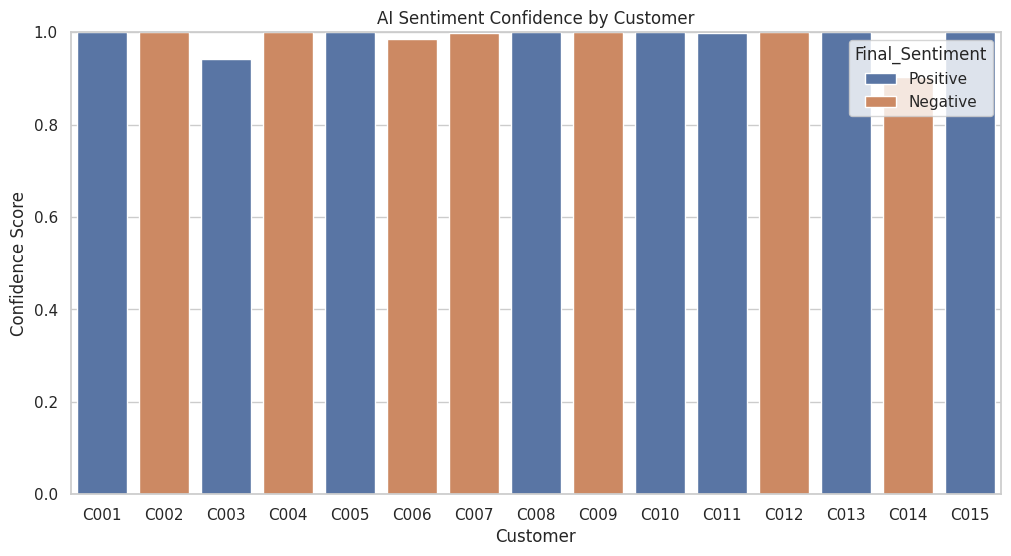

In [8]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Customer_ID",
    y="Confidence",
    hue="Final_Sentiment"
)

plt.title("AI Sentiment Confidence by Customer")
plt.xlabel("Customer")
plt.ylabel("Confidence Score")

plt.ylim(0, 1)
plt.show()

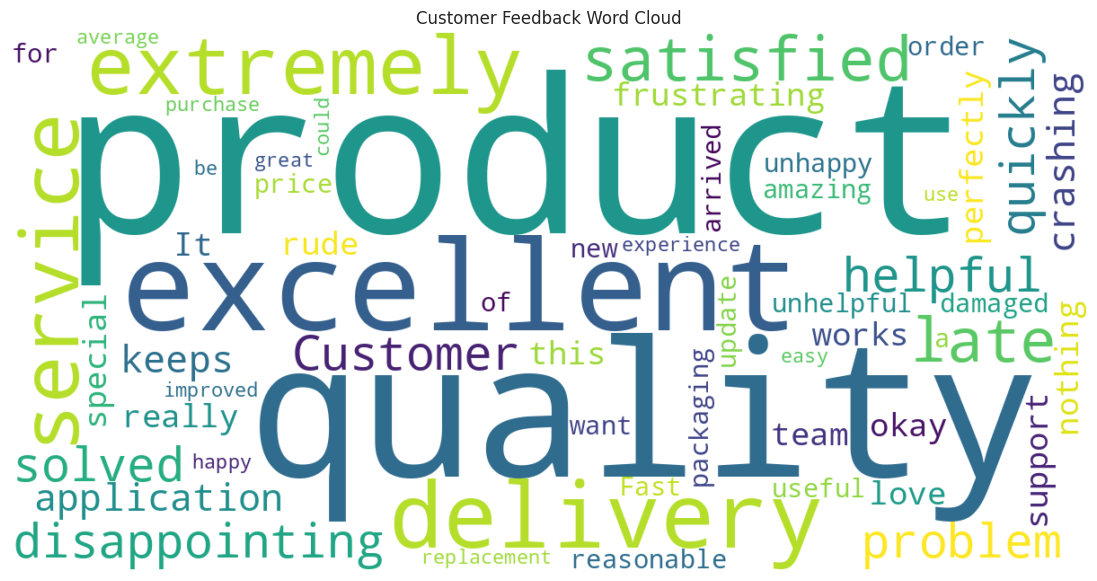

In [9]:
all_feedback = " ".join(df["Feedback"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=set([
        "the", "is", "and", "was", "very",
        "I", "am", "my", "to", "with"
    ])
).generate(all_feedback)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Customer Feedback Word Cloud")

plt.show()

In [ ]:
def analyze_feedback(feedback):
    result = sentiment_model(feedback)[0]

    label = result["label"]
    confidence = result["score"]

    if confidence < 0.65:
        sentiment = "Neutral"
    else:
        sentiment = label.capitalize()

    print("\nCustomer Feedback Analysis")
    print("--------------------------")
    print("Feedback:", feedback)
    print("Sentiment:", sentiment)
    print("Confidence:", round(confidence, 4))


analyze_feedback(
    "The product is fantastic and the customer service was excellent!"
)

In [10]:
negative_feedback = df[
    df["Final_Sentiment"] == "Negative"
]

print("Negative Customer Feedback")
print("--------------------------")

display(
    negative_feedback[
        ["Customer_ID", "Feedback", "Confidence"]
    ]
)

Negative Customer Feedback
--------------------------


,Customer_ID,Feedback,Confidence
1,C002,The delivery was extremely late and disappoint...,0.9997
3,C004,The application keeps crashing and is very fru...,0.9995
5,C006,"The product is okay, nothing special.",0.9859
6,C007,The support team was rude and unhelpful.,0.9991
8,C009,I am unhappy with the quality of the product.,0.9998
11,C012,My order arrived damaged and I want a replacem...,0.9995
13,C014,The service is average and could be improved.,0.9041


In [11]:
positive_feedback = df[
    df["Final_Sentiment"] == "Positive"
]

print("Positive Customer Feedback")
print("--------------------------")

display(
    positive_feedback[
        ["Customer_ID", "Feedback", "Confidence"]
    ]
)

Positive Customer Feedback
--------------------------


,Customer_ID,Feedback,Confidence
0,C001,The product quality is excellent and I am very...,0.9999
2,C003,Customer service was helpful and solved my pro...,0.9431
4,C005,I really love this product. It works perfectly.,0.9999
7,C008,Fast delivery and excellent packaging.,0.9998
9,C010,The new update is amazing and very useful.,0.9999
10,C011,The price is reasonable for the quality.,0.9975
12,C013,Very easy to use and the experience was great.,0.9999
14,C015,I am extremely happy with my purchase.,0.9999


In [12]:
positive = sum(df["Final_Sentiment"] == "Positive")
negative = sum(df["Final_Sentiment"] == "Negative")
neutral = sum(df["Final_Sentiment"] == "Neutral")

total = len(df)

satisfaction_score = (positive / total) * 100

print("Customer Satisfaction Report")
print("============================")
print(f"Total Feedback : {total}")
print(f"Positive       : {positive}")
print(f"Negative       : {negative}")
print(f"Neutral        : {neutral}")
print(f"Satisfaction   : {satisfaction_score:.2f}%")

Customer Satisfaction Report
Total Feedback : 15
Positive       : 8
Negative       : 7
Neutral        : 0
Satisfaction   : 53.33%


In [13]:
df.to_csv(
    "customer_feedback_analysis.csv",
    index=False
)

print("Analysis saved as customer_feedback_analysis.csv")

Analysis saved as customer_feedback_analysis.csv


In [16]:
from google.colab import files

uploaded = files.upload()

Saving deepseek_csv_20261006_ca847f.txt to deepseek_csv_20261006_ca847f.txt


In [17]:
filename = list(uploaded.keys())[0]

custom_df = pd.read_csv(filename)

custom_df.head()

,id,customer_name,email,rating,feedback,date
0,1,John Smith,john.smith@email.com,5,Excellent service! Very satisfied with the pro...,2024-01-15
1,2,Sarah Johnson,sarah.j@email.com,4,"Good quality, but shipping took longer than ex...",2024-01-18
2,3,Mike Davis,mike.davis@email.com,2,Product arrived damaged. Need replacement.,2024-01-20
3,4,Emily Brown,emily.b@email.com,5,Love it! Will definitely order again.,2024-01-22
4,5,David Wilson,david.w@email.com,3,Average product. Nothing special but works fine.,2024-01-25


In [19]:
custom_results = []

for text in custom_df["Feedback"].astype(str):
    result = sentiment_model(text)[0]

    confidence = result["score"]

    if confidence < 0.65:
        sentiment = "Neutral"
    else:
        sentiment = result["label"].capitalize()

    custom_results.append({
        "Sentiment": sentiment,
        "Confidence": round(confidence, 4)
    })

custom_results_df = pd.DataFrame(custom_results)

custom_df = pd.concat(
    [custom_df, custom_results_df],
    axis=1
)

display(custom_df)

KeyError: 'Feedback'

In [20]:
# Clean column names
custom_df.columns = custom_df.columns.str.strip()

print("Columns found:")
print(custom_df.columns.tolist())

Columns found:
['id', 'customer_name', 'email', 'rating', 'feedback', 'date']


In [21]:
custom_df.rename(columns={
    "feedback": "Feedback",
    "customer_feedback": "Feedback",
    "Customer Feedback": "Feedback",
    "Review": "Feedback",
    "review": "Feedback"
}, inplace=True)

print(custom_df.columns.tolist())

['id', 'customer_name', 'email', 'rating', 'Feedback', 'date']


In [22]:
custom_results = []

for text in custom_df["Feedback"].astype(str):
    result = sentiment_model(text)[0]

    confidence = result["score"]

    if confidence < 0.65:
        sentiment = "Neutral"
    else:
        sentiment = result["label"].capitalize()

    custom_results.append({
        "Sentiment": sentiment,
        "Confidence": round(confidence, 4)
    })

custom_results_df = pd.DataFrame(custom_results)

custom_df = pd.concat(
    [custom_df, custom_results_df],
    axis=1
)

display(custom_df)

,id,customer_name,email,rating,Feedback,date,Sentiment,Confidence
0,1,John Smith,john.smith@email.com,5,Excellent service! Very satisfied with the pro...,2024-01-15,Positive,0.9999
1,2,Sarah Johnson,sarah.j@email.com,4,"Good quality, but shipping took longer than ex...",2024-01-18,Negative,0.9796
2,3,Mike Davis,mike.davis@email.com,2,Product arrived damaged. Need replacement.,2024-01-20,Negative,0.9998
3,4,Emily Brown,emily.b@email.com,5,Love it! Will definitely order again.,2024-01-22,Positive,0.9999
4,5,David Wilson,david.w@email.com,3,Average product. Nothing special but works fine.,2024-01-25,Positive,0.9992
5,6,Lisa Anderson,lisa.a@email.com,1,Very disappointed. Did not match description.,2024-01-28,Negative,0.9998
6,7,Tom Martinez,tom.m@email.com,4,Great value for money. Recommended!,2024-02-01,Positive,0.9998
7,8,Jennifer Taylor,jen.t@email.com,5,Outstanding customer support. Very helpful team.,2024-02-03,Positive,0.9999
8,9,Robert Garcia,rob.garcia@email.com,3,Decent product but overpriced.,2024-02-05,Negative,0.9933
9,10,Amanda Lee,amanda.lee@email.com,4,Fast delivery and good packaging.,2024-02-08,Positive,0.9998
